# Noise Laboratory — Aer Noise Models, T₁/T₂ Experiments, Randomized Benchmarking

Hands-on labs building the noise channels of
[`docs/02_quantum_mechanics/05_density_matrices_and_open_systems.md`](../docs/02_quantum_mechanics/05_density_matrices_and_open_systems.md)
and running the characterization experiments of
[`docs/07_quantum_hardware/04_benchmarking_and_characterization.md`](../docs/07_quantum_hardware/04_benchmarking_and_characterization.md)
on the Aer simulator:

1. **Noise-channel zoo** — amplitude damping, depolarizing, thermal relaxation, checked
   against the closed forms in the docs.
2. **T₁ lab** — inversion recovery on an idle-gate ladder, exponential fit, recover T₁.
3. **T₂ (Ramsey) lab** — detuned fringe, damped-cosine fit, recover T₂.
4. **Randomized-benchmarking lab** — random Clifford sequences + inverse, fit `A·pᵐ + B`,
   extract error-per-Clifford, compare to the injected depolarizing noise.

All experiments use fixed seeds for reproducibility.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import DensityMatrix, Kraus, Clifford, random_clifford
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (NoiseModel, amplitude_damping_error,
                              depolarizing_error, thermal_relaxation_error)

np.set_printoptions(precision=6, suppress=True)
SEED = 12345
rng = np.random.default_rng(SEED)

## Lab 1 — Noise-channel zoo

**Goal**: build Aer's amplitude-damping, depolarizing, and thermal-relaxation channels and
verify them against the analytic forms from docs ch2/05:

- amplitude damping `γ = 1/2` on `|+⟩⟨+|` → `[[3/4, 1/(2√2)],[1/(2√2), 1/4]]`,
  Bloch vector `(1/√2, 0, 1/2)`, purity `7/8` (Exercise 4);
- depolarizing: Bloch vector shrinks uniformly, `r → (1−λ)r`;
- thermal relaxation over time `t`: `r_z → 1 + (r_z(0)−1)e^{−t/T₁}`,
  `r_{x,y} → r_{x,y}(0) e^{−t/T₂}` (docs ch2/10 Bloch solutions).

In [2]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

def bloch(rho):
    d = rho.data if hasattr(rho, "data") else rho
    return np.array([np.trace(d @ P).real for P in (X, Y, Z)])

rho_plus = DensityMatrix.from_label("+")

# --- amplitude damping, gamma = 1/2, on |+> ---
ad = Kraus(amplitude_damping_error(0.5))
out = rho_plus.evolve(ad)
print("amplitude damping γ=1/2 on |+>:\n", np.round(out.data.real, 4))
expected = np.array([[0.75, 1/(2*np.sqrt(2))], [1/(2*np.sqrt(2)), 0.25]])
assert np.allclose(out.data, expected)
print("Bloch:", bloch(out), " docs: (1/√2, 0, 1/2) =", (1/np.sqrt(2), 0, 0.5))
purity = np.trace(out.data @ out.data).real
print("purity:", purity, " docs: 7/8 ->", np.isclose(purity, 7/8), "\n")
assert np.isclose(purity, 7/8)

# --- depolarizing: r -> (1-λ) r ---
lam = 0.3
dep = Kraus(depolarizing_error(lam, 1))
for label in ["+", "r", "0"]:                     # x, y, z axis states
    rho = DensityMatrix.from_label(label)
    shrink = bloch(rho.evolve(dep)) / np.where(np.abs(bloch(rho)) > 1e-12, bloch(rho), 1)
    factor = shrink[np.abs(bloch(rho)) > 1e-12]
    print(f"depolarizing λ={lam} on |{label}>: Bloch shrink factor = {factor}")
    assert np.allclose(factor, 1 - lam)
print("uniform shrink r -> (1-λ)r confirmed (docs ch2/05, depolarizing channel)\n")

# --- thermal relaxation: Bloch exponentials with T1, T2 ---
T1, T2, t_evolve = 80.0, 60.0, 30.0               # arbitrary time units, T2 <= 2T1
th = Kraus(thermal_relaxation_error(T1, T2, t_evolve))
rho1 = DensityMatrix.from_label("1")              # r = (0,0,-1)
rz = bloch(rho1.evolve(th))[2]
rx = bloch(rho_plus.evolve(th))[0]
print(f"thermal relaxation t={t_evolve}: r_z(|1>) = {rz:.4f} "
      f"(theory 1-2e^(-t/T1) = {1-2*np.exp(-t_evolve/T1):.4f})")
print(f"                       r_x(|+>) = {rx:.4f} (theory e^(-t/T2) = {np.exp(-t_evolve/T2):.4f})")
assert np.isclose(rz, 1 - 2*np.exp(-t_evolve/T1), atol=1e-6)
assert np.isclose(rx, np.exp(-t_evolve/T2), atol=1e-6)
print("matches the Bloch-equation solutions of docs ch2/10 ✓")

amplitude damping γ=1/2 on |+>:
 [[0.75   0.3536]
 [0.3536 0.25  ]]
Bloch: [0.707107 0.       0.5     ]  docs: (1/√2, 0, 1/2) = (np.float64(0.7071067811865475), 0, 0.5)
purity: 0.8749999999999991  docs: 7/8 -> True 

depolarizing λ=0.3 on |+>: Bloch shrink factor = [0.7]
depolarizing λ=0.3 on |r>: Bloch shrink factor = [0.7]
depolarizing λ=0.3 on |0>: Bloch shrink factor = [0.7]
uniform shrink r -> (1-λ)r confirmed (docs ch2/05, depolarizing channel)

thermal relaxation t=30.0: r_z(|1>) = -0.3746 (theory 1-2e^(-t/T1) = -0.3746)
                       r_x(|+>) = 0.6065 (theory e^(-t/T2) = 0.6065)
matches the Bloch-equation solutions of docs ch2/10 ✓


## Lab 2 — T₁ experiment: inversion recovery

**Goal**: recover T₁ from a simulated experiment, exactly as in docs ch7/04:
prepare `|1⟩`, idle for `τ`, measure, fit `P(1|τ) = A e^{−τ/T₁} + B`.

The idle time is an **idle-gate ladder**: each `id` gate carries a
`thermal_relaxation_error(T₁, T₂, dt)` with `dt = 2 μs`, so `k` gates = `τ = k·dt` of decay.
Injected truth: `T₁ = 80 μs`, `T₂ = 60 μs`.

fitted T1 = 80.1 ± 1.1 us   (injected: 80.0 us)


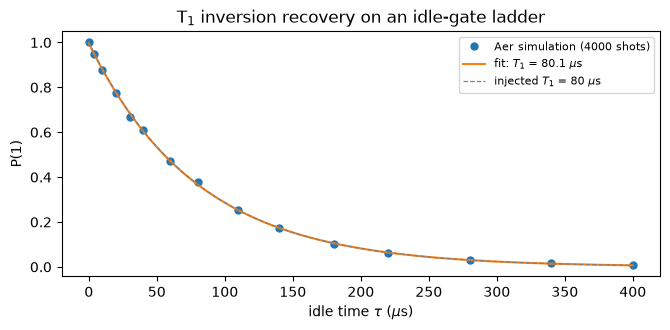

compare docs ch7/04: 'Fit P(1|τ) = A e^(-τ/T1) + B' — the protocol verbatim,
with B absorbing readout/thermal offsets (here B ≈ 0.000).


In [3]:
T1_true, T2_true = 80.0, 60.0     # microseconds
dt = 2.0                          # idle step, microseconds
shots = 4000

noise = NoiseModel()
noise.add_quantum_error(thermal_relaxation_error(T1_true, T2_true, dt), "id", [0])
sim = AerSimulator(noise_model=noise, seed_simulator=SEED)

def idle_circuit(k_steps, prep, post):
    qc = QuantumCircuit(1, 1)
    prep(qc)
    for _ in range(k_steps):
        qc.id(0)
    post(qc)
    qc.measure(0, 0)
    return qc

steps = np.array([0, 2, 5, 10, 15, 20, 30, 40, 55, 70, 90, 110, 140, 170, 200])
taus = steps * dt

circuits = [idle_circuit(int(k), lambda qc: qc.x(0), lambda qc: None) for k in steps]
tcirc = transpile(circuits, sim, optimization_level=0)
result = sim.run(tcirc, shots=shots).result()
p1 = np.array([result.get_counts(i).get("1", 0) / shots for i in range(len(steps))])

popt, pcov = curve_fit(lambda t, A, T1, B: A*np.exp(-t/T1) + B, taus, p1, p0=[1, 50, 0])
T1_fit = popt[1]
T1_err = np.sqrt(pcov[1, 1])
print(f"fitted T1 = {T1_fit:.1f} ± {T1_err:.1f} us   (injected: {T1_true} us)")
assert abs(T1_fit - T1_true) < 5 * max(T1_err, 1.0)

fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.plot(taus, p1, "o", ms=5, label="Aer simulation (4000 shots)")
tt = np.linspace(0, taus[-1], 300)
ax.plot(tt, popt[0]*np.exp(-tt/T1_fit) + popt[2], "-",
        label=f"fit: $T_1$ = {T1_fit:.1f} $\\mu$s")
ax.plot(tt, np.exp(-tt/T1_true), "--", color="gray", lw=0.9,
        label=f"injected $T_1$ = {T1_true:.0f} $\\mu$s")
ax.set_xlabel(r"idle time $\tau$ ($\mu$s)"); ax.set_ylabel("P(1)")
ax.set_title("T$_1$ inversion recovery on an idle-gate ladder")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()
print("compare docs ch7/04: 'Fit P(1|τ) = A e^(-τ/T1) + B' — the protocol verbatim,")
print("with B absorbing readout/thermal offsets (here B ≈ %.3f)." % popt[2])

## Lab 3 — T₂ Ramsey experiment

**Goal**: recover T₂ from a Ramsey fringe (docs ch7/04): prepare `|+⟩`, idle for `τ` while
accumulating an artificial detuning phase (`rz(2π δ·dt)` after each idle step — the software
analogue of detuning the drive), close with a second Hadamard, measure. Fit
`P(0|τ) = [1 + e^{−τ/T₂} cos(2πδτ + φ)]/2`.

Injected truth: `T₂ = 60 μs`, detuning `δ = 50 kHz` (period 20 μs). Since the noise model is
purely Markovian, the Ramsey decay here recovers the injected `T₂` (on hardware, quasi-static
noise would make this a shorter `T₂*` — see docs ch7/04).

fitted T2 = 59.1 us (injected 60.0),  detuning = 50.0 kHz (injected 50)


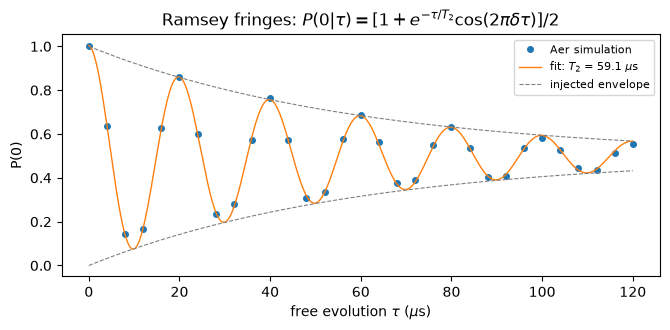

compare docs ch7/04 'T2*: Dephasing Time (Ramsey)' and docs ch2/10:
1/T2 = 1/(2T1) + 1/T_phi -> injected T_phi = 96.0 us (= 96, docs ch2/10 Ex.5)


In [4]:
delta = 0.05    # MHz (period 20 us)

def ramsey_circuit(k_steps):
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    for _ in range(int(k_steps)):
        qc.id(0)
        qc.rz(2*np.pi*delta*dt, 0)     # detuning phase per idle step
    qc.h(0)
    qc.measure(0, 0)
    return qc

steps_r = np.arange(0, 61, 2)
taus_r = steps_r * dt
circuits = [ramsey_circuit(k) for k in steps_r]
tcirc = transpile(circuits, sim, optimization_level=0)
result = sim.run(tcirc, shots=shots).result()
p0 = np.array([result.get_counts(i).get("0", 0) / shots for i in range(len(steps_r))])

def ramsey_model(t, T2, d, phi, A, B):
    return A * np.exp(-t/T2) * np.cos(2*np.pi*d*t + phi) + B

popt, pcov = curve_fit(ramsey_model, taus_r, p0, p0=[50, 0.05, 0, 0.5, 0.5],
                       maxfev=20000)
T2_fit, d_fit = popt[0], popt[1]
print(f"fitted T2 = {T2_fit:.1f} us (injected {T2_true}),  "
      f"detuning = {d_fit*1e3:.1f} kHz (injected {delta*1e3:.0f})")
assert abs(T2_fit - T2_true) < 8
assert abs(d_fit - delta) < 0.002

fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.plot(taus_r, p0, "o", ms=4, label="Aer simulation")
tt = np.linspace(0, taus_r[-1], 500)
ax.plot(tt, ramsey_model(tt, *popt), "-", lw=1, label=f"fit: $T_2$ = {T2_fit:.1f} $\\mu$s")
ax.plot(tt, 0.5 + 0.5*np.exp(-tt/T2_true), "--", color="gray", lw=0.8, label="injected envelope")
ax.plot(tt, 0.5 - 0.5*np.exp(-tt/T2_true), "--", color="gray", lw=0.8)
ax.set_xlabel(r"free evolution $\tau$ ($\mu$s)"); ax.set_ylabel("P(0)")
ax.set_title(r"Ramsey fringes: $P(0|\tau) = [1 + e^{-\tau/T_2}\cos(2\pi\delta\tau)]/2$")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()
print("compare docs ch7/04 'T2*: Dephasing Time (Ramsey)' and docs ch2/10:")
print("1/T2 = 1/(2T1) + 1/T_phi -> injected T_phi =", 1/(1/T2_true - 1/(2*T1_true)), "us (= 96, docs ch2/10 Ex.5)")

## Lab 4 — Single-qubit randomized benchmarking

**Goal**: reproduce the RB protocol of docs ch7/04 end-to-end with **known** injected noise:

1. draw `m` random Cliffords (`qiskit.quantum_info.random_clifford`), append a depolarizing
   channel with `λ = 0.02` after each one;
2. append the inverse of the whole sequence, measure;
3. fit `P(0|m) = A·pᵐ + B` and extract the error per Clifford `r = (1−p)/2`.

For depolarizing noise the decay parameter should equal `p = 1 − λ` (the Bloch-vector shrink
factor), so the expected error per Clifford is `r = λ/2 = 0.01` — the fit is checked against
the injected truth, exactly the comparison the docs' worked example performs on real data.

m =   1: mean P(0) = 0.9905


m =   2: mean P(0) = 0.9787


m =   4: mean P(0) = 0.9618


m =   8: mean P(0) = 0.9280


m =  16: mean P(0) = 0.8607


m =  32: mean P(0) = 0.7617


m =  64: mean P(0) = 0.6343


m =  96: mean P(0) = 0.5727

fit: A = 0.499, p = 0.9798, B = 0.502
error per Clifford: fitted r = 0.0101  vs injected λ/2 = 0.0100
decay parameter:    fitted p = 0.9798  vs injected 1-λ = 0.9800


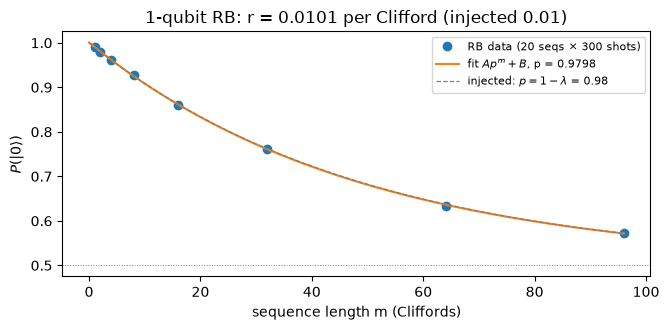

compare docs ch7/04 worked example: same fit form, same r = (1-p)/2 formula,
same B ≈ 1/2 asymptote (a long random Clifford sequence fully depolarizes the qubit).


In [5]:
lam_inj = 0.02
dep_channel = Kraus(depolarizing_error(lam_inj, 1)).to_instruction()
rb_sim = AerSimulator(seed_simulator=SEED)   # noise injected explicitly per Clifford

def rb_circuit(m, seq_rng):
    qc = QuantumCircuit(1, 1)
    total = Clifford(QuantumCircuit(1))
    for _ in range(m):
        c = random_clifford(1, seed=int(seq_rng.integers(1e9)))
        qc.compose(c.to_circuit(), inplace=True)
        qc.append(dep_channel, [0])          # noise after every Clifford
        total = total.compose(c)
    qc.compose(total.adjoint().to_circuit(), inplace=True)   # perfect inverse
    qc.measure(0, 0)
    return qc

lengths = np.array([1, 2, 4, 8, 16, 32, 64, 96])
n_seq, shots_rb = 20, 300
seq_rng = np.random.default_rng(SEED)

survival = []
for m in lengths:
    circs = [rb_circuit(int(m), seq_rng) for _ in range(n_seq)]
    tcirc = transpile(circs, rb_sim, optimization_level=0)
    res = rb_sim.run(tcirc, shots=shots_rb).result()
    p = np.mean([res.get_counts(i).get("0", 0) / shots_rb for i in range(n_seq)])
    survival.append(p)
    print(f"m = {m:3d}: mean P(0) = {p:.4f}")
survival = np.array(survival)

popt, pcov = curve_fit(lambda m, A, p, B: A*p**m + B, lengths, survival,
                       p0=[0.5, 0.98, 0.5], maxfev=20000)
A_fit, p_fit, B_fit = popt
r_fit = (1 - p_fit) / 2
r_inj = lam_inj / 2
print(f"\nfit: A = {A_fit:.3f}, p = {p_fit:.4f}, B = {B_fit:.3f}")
print(f"error per Clifford: fitted r = {r_fit:.4f}  vs injected λ/2 = {r_inj:.4f}")
print(f"decay parameter:    fitted p = {p_fit:.4f}  vs injected 1-λ = {1-lam_inj:.4f}")
assert abs(p_fit - (1 - lam_inj)) < 0.004
assert abs(r_fit - r_inj) < 0.002

mm = np.linspace(0, lengths[-1], 300)
fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.plot(lengths, survival, "o", label=f"RB data ({n_seq} seqs × {shots_rb} shots)")
ax.plot(mm, A_fit*p_fit**mm + B_fit, "-", label=f"fit $Ap^m+B$, p = {p_fit:.4f}")
ax.plot(mm, 0.5*(1-lam_inj)**mm + 0.5, "--", color="gray", lw=0.9,
        label=f"injected: $p = 1-\\lambda$ = {1-lam_inj}")
ax.axhline(0.5, color="gray", ls=":", lw=0.7)
ax.set_xlabel("sequence length m (Cliffords)"); ax.set_ylabel(r"$P(|0\rangle)$")
ax.set_title(f"1-qubit RB: r = {r_fit:.4f} per Clifford (injected {r_inj})")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()
print("compare docs ch7/04 worked example: same fit form, same r = (1-p)/2 formula,")
print("same B ≈ 1/2 asymptote (a long random Clifford sequence fully depolarizes the qubit).")

### Wrap-up: what these labs demonstrated

| Lab | Docs section | Recovered vs. injected |
|-----|-------------|------------------------|
| Channel zoo | ch2/05 noise channels, ch2/10 Bloch solutions | closed forms exact |
| T₁ inversion recovery | ch7/04 "T1: Longitudinal Relaxation" | `T₁ ≈ 80 μs` |
| Ramsey | ch7/04 "T2*: Dephasing (Ramsey)" | `T₂ ≈ 60 μs`, `δ ≈ 50 kHz` |
| Randomized benchmarking | ch7/04 "Randomized Benchmarking" | `r ≈ λ/2 = 0.01`/Clifford |

The same fitting code applied to real-device data is exactly the analysis pipeline the docs
describe — only the data source changes.